# **FRAMEWORK V7 DATASET MAESTRO - MODELADO**


## **M0. Configuración del Experimento**

In [1]:
#==========================================================================================
# SCRIPT 32
# CONFIGURACIÓN DEL EXPERIMENTO DE MODELADO
#==========================================================================================

EXPERIMENTO = "Exp04"

#DOMINIO = "Gestión Hídrica"

#VARIABLE_OBJETIVO = "VolumenUtilDiarioMasa"

#METODO_TRANSFORMACION = "Escalado MinMax"

In [2]:
#==========================================================================================
# LIBRERÍAS
#==========================================================================================

import numpy as np

import pandas as pd

import tensorflow as tf

from tensorflow import keras

print()

print("="*90)
print("LIBRERÍAS CARGADAS")
print("="*90)


LIBRERÍAS CARGADAS


In [3]:
#==========================================================================================
# CARGA DE SECUENCIAS TEMPORALES Y REGISTRO DE PREPARACION
#==========================================================================================
import numpy as np
import pandas as pd

# Base URL for the sequences and metadata
base_url = f"https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/{EXPERIMENTO}/"

# URLs completas de los archivos
x_sequence_url = base_url + "secuencias_X.npy"
y_sequence_url = base_url + "secuencias_y.npy"
metadata_sequence_url = base_url + "metadata_secuencias.csv"

# Nombres de archivo locales
x_sequence_filename = "secuencias_X.npy"
y_sequence_filename = "secuencias_y.npy"
metadata_sequence_filename = "metadata_secuencias.csv"

# Descargar los archivos
!wget -O {x_sequence_filename} {x_sequence_url}
!wget -O {y_sequence_filename} {y_sequence_url}
!wget -O {metadata_sequence_filename} {metadata_sequence_url}

secuencias_X = np.load(x_sequence_filename)
secuencias_y = np.load(y_sequence_filename)
metadata = pd.read_csv(metadata_sequence_filename)

print()

print("="*90)
print("SECUENCIAS CARGADAS")
print("="*90)

print()

print(f"Secuencias X : {secuencias_X.shape}")

print(f"Secuencias y : {secuencias_y.shape}")

print()

display(metadata)

--2026-07-31 01:09:23--  https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp04/secuencias_X.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 396416 (387K) [application/octet-stream]
Saving to: ‘secuencias_X.npy’

secuencias_X.npy    100%[===================>] 387.12K  --.-KB/s    in 0.03s   

2026-07-31 01:09:23 (13.4 MB/s) - ‘secuencias_X.npy’ saved [396416/396416]

--2026-07-31 01:09:23--  https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp04/secuencias_y.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connectin

,Parametro,Valor
0,Experimento,Exp04
1,Dominio,Gestión Hídrica
2,Tipo Problema,Regresión
3,Modelo,LSTM
4,Variable Objetivo,VolumenUtilDiarioMasa
5,Ventana,12
6,Horizonte,1
7,Variables Predictoras,Precipitacion_mm;ONI;Radiacion_Solar;Humedad_R...
8,Variables Modelo,8
9,Numero de Secuencias,516


In [4]:
# URL y nombre de archivo para registro_preparacion.xlsx
registro_preparacion_url = base_url + "registro_preparacion.xlsx"
registro_preparacion_filename = "registro_preparacion.xlsx"

# Descargar el archivo
!wget -O {registro_preparacion_filename} {registro_preparacion_url}

registro_preparacion = pd.read_excel(registro_preparacion_filename)

print()
print("="*90)
print("REGISTRO DE PREPARACIÓN CARGADO")
print("="*90)
print()
display(registro_preparacion)

--2026-07-31 01:09:35--  https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp04/registro_preparacion.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5195 (5.1K) [application/octet-stream]
Saving to: ‘registro_preparacion.xlsx’

registro_preparacio 100%[===================>]   5.07K  --.-KB/s    in 0s      

2026-07-31 01:09:35 (46.2 MB/s) - ‘registro_preparacion.xlsx’ saved [5195/5195]


REGISTRO DE PREPARACIÓN CARGADO



,Parametro,Valor
0,Experimento,Exp04
1,Dominio,Gestión Hídrica
2,Variable Objetivo,VolumenUtilDiarioMasa
3,Ventana Temporal,12
4,Horizonte,1
5,Variables Predictoras,8
6,Observaciones,528
7,Número de Secuencias,516
8,Método de Transformación,RobustScaler


In [5]:
registro_preparacion = pd.read_excel("registro_preparacion.xlsx")

DOMINIO = registro_preparacion.loc[
    registro_preparacion["Parametro"]=="Dominio",
    "Valor"
].iloc[0]

VARIABLE_OBJETIVO = registro_preparacion.loc[
    registro_preparacion["Parametro"]=="Variable Objetivo",
    "Valor"
].iloc[0]

VENTANA = int(
    registro_preparacion.loc[
        registro_preparacion["Parametro"]=="Ventana Temporal",
        "Valor"
    ].iloc[0]
)

HORIZONTE = int(
    registro_preparacion.loc[
        registro_preparacion["Parametro"]=="Horizonte",
        "Valor"
    ].iloc[0]
)

METODO_TRANSFORMACION = registro_preparacion.loc[
    registro_preparacion["Parametro"]=="Método de Transformación",
    "Valor"
].iloc[0]

In [6]:
display(registro_preparacion)

,Parametro,Valor
0,Experimento,Exp04
1,Dominio,Gestión Hídrica
2,Variable Objetivo,VolumenUtilDiarioMasa
3,Ventana Temporal,12
4,Horizonte,1
5,Variables Predictoras,8
6,Observaciones,528
7,Número de Secuencias,516
8,Método de Transformación,RobustScaler


In [7]:
#==========================================================================================
# VALIDACIÓN DEL EXPERIMENTO
#==========================================================================================

print()

print("="*90)
print("VALIDACIÓN")
print("="*90)

print()

if len(secuencias_X) != len(secuencias_y):

    raise Exception(

        "Las secuencias X y y no tienen la misma cantidad de registros."

    )

print("Secuencias consistentes.")

print()

print(f"Número de muestras : {len(secuencias_X)}")


VALIDACIÓN

Secuencias consistentes.

Número de muestras : 516


## **M1. Construcción de Tensores**

In [8]:
#==========================================================================================
# CONSTRUCCIÓN DEL TENSOR X
#==========================================================================================

X = np.array(

    secuencias_X,

    dtype=np.float32

)

print()

print("="*90)
print("TENSOR X")
print("="*90)

print()

print(f"Forma : {X.shape}")


TENSOR X

Forma : (516, 12, 8)


In [9]:
#==========================================================================================
# CONSTRUCCIÓN DEL TENSOR y
#==========================================================================================

y = np.array(

    secuencias_y,

    dtype=np.float32

)

print()

print("="*90)
print("TENSOR y")
print("="*90)

print()

print(f"Forma : {y.shape}")


TENSOR y

Forma : (516,)


In [10]:
#==========================================================================================
# VALIDACIÓN DE LOS TENSORES
#==========================================================================================

print()

print("="*90)
print("VALIDACIÓN")
print("="*90)

print()

print(f"Tensor X : {X.shape}")

print(f"Tensor y : {y.shape}")

print()

print(f"Ventana temporal      : {X.shape[1]}")

print(f"Variables predictoras : {X.shape[2]}")

print()

if X.shape[0] == y.shape[0]:

    print("Resultado : TENSORES VÁLIDOS")

else:

    raise Exception(

        "El número de muestras entre X e y no coincide."

    )


VALIDACIÓN

Tensor X : (516, 12, 8)
Tensor y : (516,)

Ventana temporal      : 12
Variables predictoras : 8

Resultado : TENSORES VÁLIDOS


In [11]:
#==========================================================================================
# EXPORTACIÓN DEL TENSOR X
#==========================================================================================

import os

CARPETA_TENSORES = f"tensores/{EXPERIMENTO}"

os.makedirs(

    CARPETA_TENSORES,

    exist_ok=True

)

np.save(

    f"{CARPETA_TENSORES}/tensor_X.npy",

    X

)

print()

print("="*90)
print("TENSOR X EXPORTADO")
print("="*90)

print()

print(f"{CARPETA_TENSORES}/tensor_X.npy")


TENSOR X EXPORTADO

tensores/Exp04/tensor_X.npy


In [12]:
#==========================================================================================
# EXPORTACIÓN DEL TENSOR y
#==========================================================================================

np.save(

    f"{CARPETA_TENSORES}/tensor_y.npy",

    y

)

print()

print("="*90)
print("TENSOR y EXPORTADO")
print("="*90)

print()

print(f"{CARPETA_TENSORES}/tensor_y.npy")


TENSOR y EXPORTADO

tensores/Exp04/tensor_y.npy


In [13]:
#==========================================================================================
# METADATA DEL TENSOR
#==========================================================================================

HORIZONTE = metadata.loc[
    metadata["Parametro"] == "Horizonte",
    "Valor"
].iloc[0]

# Recuperar nombres de las variables desde metadata_secuencias
VARIABLES_MODELO = (
    metadata.loc[
        metadata["Parametro"] == "Variables Predictoras",
        "Valor"
    ]
    .iloc[0]
)

metadata_tensor = pd.DataFrame({

    "Parametro":[

        "Experimento",

        "Dominio",

        "Variable Objetivo",

        "Ventana",

        "Horizonte",

        "Variables Predictoras",

        "Variables Modelo",

        "Metodo Transformacion",

        "Numero Secuencias",

        "Fecha Generacion",

        "Tensor X",

        "Tensor y"

    ],

    "Valor":[

        EXPERIMENTO,

        DOMINIO,

        VARIABLE_OBJETIVO,

        X.shape[1],

        HORIZONTE,

        X.shape[2],

        VARIABLES_MODELO,

        METODO_TRANSFORMACION,

        X.shape[0],

        pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),

        "tensor_X.npy",

        "tensor_y.npy"

    ]

})

#==========================================================================================
# EXPORTACIÓN DE LA METADATA
#==========================================================================================

metadata_tensor.to_csv(

    f"{CARPETA_TENSORES}/metadata_tensor.csv",

    index=False,

    encoding="utf-8-sig"

)

metadata_tensor.to_excel(

    f"{CARPETA_TENSORES}/metadata_tensor.xlsx",

    index=False

)

print()

print("="*90)
print("METADATA DEL TENSOR EXPORTADA")
print("="*90)

print()

print(f"{CARPETA_TENSORES}/metadata_tensor.csv")

print(f"{CARPETA_TENSORES}/metadata_tensor.xlsx")

print()

display(metadata_tensor)



METADATA DEL TENSOR EXPORTADA

tensores/Exp04/metadata_tensor.csv
tensores/Exp04/metadata_tensor.xlsx



,Parametro,Valor
0,Experimento,Exp04
1,Dominio,Gestión Hídrica
2,Variable Objetivo,VolumenUtilDiarioMasa
3,Ventana,12
4,Horizonte,1
5,Variables Predictoras,8
6,Variables Modelo,Precipitacion_mm;ONI;Radiacion_Solar;Humedad_R...
7,Metodo Transformacion,RobustScaler
8,Numero Secuencias,516
9,Fecha Generacion,2026-07-31 01:15


## **M2. División Temporal del Conjunto de Datos**

Objetivo: Dividir los tensores en:

* Entrenamiento (70%)
* Validación (15%)
* Prueba (15%)

manteniendo el orden temporal.

In [14]:
#==========================================================================================
# CONFIGURACIÓN DE LA DIVISIÓN TEMPORAL
#==========================================================================================

PORCENTAJE_TRAIN = 0.70

PORCENTAJE_VALIDACION = 0.15

PORCENTAJE_PRUEBA = 0.15

print()

print("="*90)
print("CONFIGURACIÓN DE LA DIVISIÓN")
print("="*90)

print()

print(f"Entrenamiento : {PORCENTAJE_TRAIN:.0%}")
print(f"Validación    : {PORCENTAJE_VALIDACION:.0%}")
print(f"Prueba        : {PORCENTAJE_PRUEBA:.0%}")


CONFIGURACIÓN DE LA DIVISIÓN

Entrenamiento : 70%
Validación    : 15%
Prueba        : 15%


In [15]:
#==========================================================================================
# CÁLCULO DE LOS ÍNDICES
#==========================================================================================

n = len(X)

indice_train = int(n * PORCENTAJE_TRAIN)

indice_validacion = int(n * (PORCENTAJE_TRAIN + PORCENTAJE_VALIDACION))

print()

print("="*90)
print("ÍNDICES DE CORTE")
print("="*90)

print()

print(f"Total muestras       : {n}")

print(f"Fin entrenamiento    : {indice_train}")

print(f"Fin validación       : {indice_validacion}")


ÍNDICES DE CORTE

Total muestras       : 516
Fin entrenamiento    : 361
Fin validación       : 438


In [16]:
#==========================================================================================
# DIVISIÓN TEMPORAL
#==========================================================================================

X_train = X[:indice_train]

y_train = y[:indice_train]

X_valid = X[indice_train:indice_validacion]

y_valid = y[indice_train:indice_validacion]

X_test = X[indice_validacion:]

y_test = y[indice_validacion:]

In [17]:
#==========================================================================================
# RESUMEN DE LA DIVISIÓN
#==========================================================================================

print()

print("="*90)
print("RESUMEN")
print("="*90)

print()

print(f"Entrenamiento : {X_train.shape}")

print(f"Validación    : {X_valid.shape}")

print(f"Prueba        : {X_test.shape}")


RESUMEN

Entrenamiento : (361, 12, 8)
Validación    : (77, 12, 8)
Prueba        : (78, 12, 8)


In [18]:
#==========================================================================================
# VALIDACIÓN DE LA DIVISIÓN
#==========================================================================================

print()

print("="*90)
print("VALIDACIÓN")
print("="*90)

print()

print(f"Total muestras : {len(X)}")

print(

    f"Total dividido : "

    f"{len(X_train)+len(X_valid)+len(X_test)}"

)

if len(X) == len(X_train)+len(X_valid)+len(X_test):

    print()

    print("Resultado : DIVISIÓN CORRECTA")

else:

    raise Exception(

        "La división temporal presenta inconsistencias."

    )


VALIDACIÓN

Total muestras : 516
Total dividido : 516

Resultado : DIVISIÓN CORRECTA


In [19]:
print('\n==========================================================================================')
print('RANGO DE VALORES DE Y')
print('==========================================================================================\n')

print(f"y_train - Min: {y_train.min():.4f}, Max: {y_train.max():.4f}")
print(f"y_valid - Min: {y_valid.min():.4f}, Max: {y_valid.max():.4f}")
print(f"y_test  - Min: {y_test.min():.4f}, Max: {y_test.max():.4f}")


RANGO DE VALORES DE Y

y_train - Min: 0.0000, Max: 1.0000
y_valid - Min: 0.0000, Max: 1.0000
y_test  - Min: 0.0000, Max: 1.0000


## **M3. Construcción del Modelo de Machine Learning**

In [20]:
#==========================================================================================
# CONFIGURACIÓN DEL MODELO
#==========================================================================================

TIPO_MODELO = "LSTM"

UNIDADES_LSTM = 32

DROPOUT = 0.20

ACTIVACION = "tanh"

print()

print("="*90)
print("CONFIGURACIÓN DEL MODELO")
print("="*90)

print()

print(f"Modelo              : {TIPO_MODELO}")

print(f"Neuronas LSTM       : {UNIDADES_LSTM}")

print(f"Dropout             : {DROPOUT}")

print(f"Activación          : {ACTIVACION}")


CONFIGURACIÓN DEL MODELO

Modelo              : LSTM
Neuronas LSTM       : 32
Dropout             : 0.2
Activación          : tanh


In [21]:
#==========================================================================================
# CONSTRUCCIÓN DEL MODELO
#==========================================================================================

from tensorflow import keras

if TIPO_MODELO == "LSTM":

    modelo = keras.Sequential([

        keras.layers.Input(

            shape=(

                X_train.shape[1],

                X_train.shape[2]

            )

        ),

        keras.layers.LSTM(

            units=UNIDADES_LSTM,

            activation=ACTIVACION

        ),

        keras.layers.Dropout(

            DROPOUT

        ),

        keras.layers.Dense(

            1

        )

    ])

else:

    raise Exception(

        f"Modelo '{TIPO_MODELO}' no soportado por el Framework."

    )

## **M4. Configuración del Entrenamiento**

In [22]:
#==========================================================================================
# CONFIGURACIÓN DEL ENTRENAMIENTO
#==========================================================================================

EPOCAS = 100

BATCH_SIZE = 32

LEARNING_RATE = 0.001

PACIENCIA = 10

print()

print("="*90)
print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print("="*90)

print()

print(f"Épocas           : {EPOCAS}")

print(f"Batch Size       : {BATCH_SIZE}")

print(f"Learning Rate    : {LEARNING_RATE}")

print(f"Early Stopping   : {PACIENCIA}")

USAR_CLASS_WEIGHT = False      # Exp01
# USAR_CLASS_WEIGHT = True     # Exp01-V2
USAR_SMOTE = False            # Exp01-V3


CONFIGURACIÓN DEL ENTRENAMIENTO

Épocas           : 100
Batch Size       : 32
Learning Rate    : 0.001
Early Stopping   : 10


In [23]:
#==========================================================================================
# EARLY STOPPING
#==========================================================================================

import tensorflow as tf

early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=PACIENCIA,

    restore_best_weights=True

)

print()

print("="*90)
print("CALLBACKS")
print("="*90)

print()

print("EarlyStopping configurado correctamente.")


CALLBACKS

EarlyStopping configurado correctamente.


In [25]:
TIPO_PROBLEMA = metadata.loc[
    metadata["Parametro"] == "Tipo Problema",
    "Valor"
].iloc[0]

In [26]:
#==========================================================================================
# COMPILACIÓN DEL MODELO
#==========================================================================================

if TIPO_PROBLEMA == "Clasificación":

    LOSS = "binary_crossentropy"

    METRICAS = ["accuracy"]

else:

    LOSS = "mse"

    METRICAS = [

        tf.keras.metrics.MeanAbsoluteError(name="mae"),

        tf.keras.metrics.RootMeanSquaredError(name="rmse")

    ]

modelo.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss=LOSS,

    metrics=METRICAS

)

print()

print("="*90)
print("MODELO COMPILADO")
print("="*90)

print()

print(f"Tipo problema : {TIPO_PROBLEMA}")

print(f"Loss          : {LOSS}")

print(f"Métricas      : {METRICAS}")

print()

print("Compilación finalizada correctamente.")


MODELO COMPILADO

Tipo problema : Regresión
Loss          : mse
Métricas      : [<MeanAbsoluteError name=mae>, <RootMeanSquaredError name=rmse>]

Compilación finalizada correctamente.


In [27]:
#==========================================================================================
# M4.4 BALANCEO AUTOMÁTICO DE CLASES
#==========================================================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weight = None

if USAR_CLASS_WEIGHT:

    clases = np.unique(y_train)

    pesos = compute_class_weight(

        class_weight="balanced",

        classes=clases,

        y=y_train

    )

    class_weight = dict(zip(clases, pesos))

    print()
    print("="*90)
    print("BALANCEO AUTOMÁTICO DE CLASES")
    print("="*90)
    print()
    print(class_weight)

else:

    print()
    print("="*90)
    print("BALANCEO AUTOMÁTICO DE CLASES")
    print("="*90)
    print()
    print("No se utiliza balanceo de clases en este experimento.")


BALANCEO AUTOMÁTICO DE CLASES

No se utiliza balanceo de clases en este experimento.


In [29]:
#==========================================================================================
# M4.5
# BALANCEO MEDIANTE SMOTE
#==========================================================================================

from imblearn.over_sampling import SMOTE

VENTANA = X_train.shape[1] # Define VENTANA here

if USAR_SMOTE:

    smote = SMOTE(

        random_state=42

    )

    X_train_smote, y_train_smote = smote.fit_resample(

        X_train.reshape(

            X_train.shape[0],
            X_train.shape[1] * X_train.shape[2]

        ),

        y_train

    )

    X_train_smote = X_train_smote.reshape(

        X_train_smote.shape[0],
        VENTANA,
        X_train.shape[2]

    )

    print()

    print("="*90)
    print("SMOTE APLICADO")
    print("="*90)

    print()

    print(X_train_smote.shape)

    print(y_train_smote.shape)

else:

    print()
    print("="*90)
    print("SMOTE NO APLICADO")
    print("="*90)
    print()
    print("No se utiliza SMOTE en este experimento.")


SMOTE NO APLICADO

No se utiliza SMOTE en este experimento.


## **M5. Entrenamiento del Modelo**

In [30]:
#==========================================================================================
# M5
# ENTRENAMIENTO DEL MODELO
#==========================================================================================

import time

#----------------------------------------------------
# Selección automática del conjunto de entrenamiento
#----------------------------------------------------

if USAR_SMOTE:

    X_entrenamiento = X_train_smote
    y_entrenamiento = y_train_smote

else:

    X_entrenamiento = X_train
    y_entrenamiento = y_train

print()

print("="*90)
print("CONJUNTO DE ENTRENAMIENTO SELECCIONADO")
print("="*90)

print()

print(f"X_entrenamiento : {X_entrenamiento.shape}")
print(f"y_entrenamiento : {y_entrenamiento.shape}")

if USAR_SMOTE:

    print("Balanceo utilizado : SMOTE")

elif USAR_CLASS_WEIGHT:

    print("Balanceo utilizado : Class Weight")

else:

    print("Balanceo utilizado : Ninguno")

#----------------------------------------------------
# Entrenamiento
#----------------------------------------------------

inicio = time.time()

historial = modelo.fit(

    X_entrenamiento,

    y_entrenamiento,

    validation_data=(

        X_valid,
        y_valid

    ),

    epochs=EPOCAS,

    batch_size=BATCH_SIZE,

    callbacks=[

        early_stopping

    ],

    verbose=1,

    class_weight=class_weight

)

fin = time.time()

TIEMPO_ENTRENAMIENTO = fin - inicio

print()

print("="*90)
print("ENTRENAMIENTO FINALIZADO")
print("="*90)

print()

print(f"Tiempo de entrenamiento : {TIEMPO_ENTRENAMIENTO:.2f} segundos")


CONJUNTO DE ENTRENAMIENTO SELECCIONADO

X_entrenamiento : (361, 12, 8)
y_entrenamiento : (361,)
Balanceo utilizado : Ninguno
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0759 - mae: 0.1758 - rmse: 0.2755 - val_loss: 0.1363 - val_mae: 0.2789 - val_rmse: 0.3692
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0505 - mae: 0.1482 - rmse: 0.2247 - val_loss: 0.0868 - val_mae: 0.2068 - val_rmse: 0.2947
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0361 - mae: 0.1312 - rmse: 0.1899 - val_loss: 0.0713 - val_mae: 0.1668 - val_rmse: 0.2670
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0346 - mae: 0.1196 - rmse: 0.1860 - val_loss: 0.0603 - val_mae: 0.1396 - val_rmse: 0.2455
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0302 - mae: 0.1146 - rmse: 0.1739 - val_loss: 0.0548 - val_mae: 0.1306 - val_rmse: 0.2341
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0276 - mae: 0.1069 - rmse: 0.1660 - val_loss: 0.0514

In [31]:
#==========================================================================================
# RESUMEN DEL ENTRENAMIENTO
#==========================================================================================

print()

print("="*90)
print("ENTRENAMIENTO FINALIZADO")
print("="*90)

print()

print(f"Épocas ejecutadas : {len(historial.history['loss'])}")

print(f"Tiempo (segundos) : {TIEMPO_ENTRENAMIENTO:.2f}")


ENTRENAMIENTO FINALIZADO

Épocas ejecutadas : 35
Tiempo (segundos) : 10.65


In [32]:
#==========================================================================================
# HISTORIAL DEL ENTRENAMIENTO
#==========================================================================================

historial_df = pd.DataFrame(

    historial.history

)

print()

print("="*90)
print("HISTORIAL")
print("="*90)

print()

display(historial_df.head())


HISTORIAL



,loss,mae,rmse,val_loss,val_mae,val_rmse
0,0.075887,0.175812,0.275477,0.136338,0.278863,0.369240
1,0.050491,0.148151,0.224702,0.086829,0.206809,0.294668
2,0.036073,0.131202,0.189928,0.071312,0.166843,0.267042
3,0.034588,0.119644,0.185979,0.060289,0.139648,0.245539
4,0.030241,0.114617,0.173899,0.054813,0.130624,0.234122


In [34]:
#==========================================================================================
# MÉTRICAS FINALES
#==========================================================================================

LOSS_FINAL = historial.history["loss"][-1]

VAL_LOSS_FINAL = historial.history["val_loss"][-1]

print()

print("="*90)
print("RESULTADOS FINALES")
print("="*90)

print()

print(f"Loss entrenamiento      : {LOSS_FINAL:.4f}")

print(f"Loss validación         : {VAL_LOSS_FINAL:.4f}")

print()

if TIPO_PROBLEMA == "Clasificación":
    ACC_FINAL = historial.history["accuracy"][-1]
    VAL_ACC_FINAL = historial.history["val_accuracy"][-1]
    print(f"Accuracy entrenamiento  : {ACC_FINAL:.4f}")
    print(f"Accuracy validación     : {VAL_ACC_FINAL:.4f}")
elif TIPO_PROBLEMA == "Regresión":
    MAE_FINAL = historial.history["mae"][-1]
    VAL_MAE_FINAL = historial.history["val_mae"][-1]
    RMSE_FINAL = historial.history["rmse"][-1]
    VAL_RMSE_FINAL = historial.history["val_rmse"][-1]
    print(f"MAE entrenamiento       : {MAE_FINAL:.4f}")
    print(f"MAE validación          : {VAL_MAE_FINAL:.4f}")
    print()
    print(f"RMSE entrenamiento      : {RMSE_FINAL:.4f}")
    print(f"RMSE validación         : {VAL_RMSE_FINAL:.4f}")



RESULTADOS FINALES

Loss entrenamiento      : 0.0081
Loss validación         : 0.0386

MAE entrenamiento       : 0.0595
MAE validación          : 0.1653

RMSE entrenamiento      : 0.0899
RMSE validación         : 0.1964


## **M6. Evaluación del Modelo**

In [36]:
#==========================================================================================
# M6.1 EVALUACIÓN GENERAL DEL MODELO
#==========================================================================================

if TIPO_PROBLEMA == "Clasificación":
    LOSS_TEST, ACC_TEST = modelo.evaluate(
        X_test,
        y_test,
        verbose=0
    )
    MAE_TEST = None  # Not applicable for classification
    RMSE_TEST = None # Not applicable for classification

elif TIPO_PROBLEMA == "Regresión":
    LOSS_TEST, MAE_TEST, RMSE_TEST = modelo.evaluate(
        X_test,
        y_test,
        verbose=0
    )
    ACC_TEST = None # Not applicable for regression

print()

print("="*90)
print("M6.1 EVALUACIÓN GENERAL DEL MODELO")
print("="*90)

print()

print(f"Loss (Prueba)       : {LOSS_TEST:.4f}")

if TIPO_PROBLEMA == "Clasificación":
    print(f"Accuracy (Prueba)   : {ACC_TEST:.4f}")
elif TIPO_PROBLEMA == "Regresión":
    print(f"MAE (Prueba)        : {MAE_TEST:.4f}")
    print(f"RMSE (Prueba)       : {RMSE_TEST:.4f}")

print()

if TIPO_PROBLEMA == "Clasificación":
    if ACC_TEST >= 0.90:
        estado="Excelente"
    elif ACC_TEST >=0.80:
        estado="Bueno"
    elif ACC_TEST >=0.70:
        estado="Aceptable"
    else:
        estado="Requiere ajustes"
elif TIPO_PROBLEMA == "Regresión":
    # For regression, we'll use RMSE as a primary indicator for 'estado'
    # You might adjust these thresholds based on your specific problem and acceptable error.
    if RMSE_TEST <= 0.05:
        estado="Excelente" # Very low error
    elif RMSE_TEST <= 0.15:
        estado="Bueno"     # Acceptable low error
    elif RMSE_TEST <= 0.30:
        estado="Aceptable" # Moderate error
    else:
        estado="Requiere ajustes" # High error

print(f"Estado del modelo   : {estado}")


M6.1 EVALUACIÓN GENERAL DEL MODELO

Loss (Prueba)       : 0.0670
MAE (Prueba)        : 0.2191
RMSE (Prueba)       : 0.2589

Estado del modelo   : Aceptable


In [37]:
#==========================================================================================
# GENERACIÓN DE PROBABILIDADES
#==========================================================================================

probabilidades = modelo.predict(

    X_test,

    verbose=0

)

predicciones = (

    probabilidades >=0.50

).astype(int)

print()

print("="*90)
print("M6.2 GENERACIÓN DE PREDICCIONES")
print("="*90)

print()

print(f"Observaciones evaluadas : {len(predicciones)}")

print(f"Umbral de decisión      : 0.50")


M6.2 GENERACIÓN DE PREDICCIONES

Observaciones evaluadas : 78
Umbral de decisión      : 0.50


In [38]:
#==========================================================================================
# COMPARACIÓN ENTRE VALORES REALES Y PREDICHOS
#==========================================================================================

comparacion = pd.DataFrame({

    "Real":y_test.astype(int),

    "Probabilidad":probabilidades.flatten(),

    "Predicción":predicciones.flatten()

})

print()

print("="*90)
print("M6.3 COMPARACIÓN DE RESULTADOS")
print("="*90)

display(comparacion.head(20))


M6.3 COMPARACIÓN DE RESULTADOS


,Real,Probabilidad,Predicción
0,0,-0.162827,0
1,0,-0.197390,0
2,0,-0.186251,0
3,0,-0.167048,0
4,0,-0.140804,0
5,0,-0.127700,0
6,0,-0.140847,0
7,0,-0.183537,0
8,0,-0.241306,0
9,0,-0.164291,0


In [39]:
#==========================================================================================
# M6.4 MÉTRICAS DE CLASIFICACIÓN
#==========================================================================================

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report

)

#-------------------------------------------------------
# Cálculo de métricas
#-------------------------------------------------------

accuracy = accuracy_score(

    y_test,

    predicciones

)

precision = precision_score(

    y_test,

    predicciones,

    zero_division=0

)

recall = recall_score(

    y_test,

    predicciones,

    zero_division=0

)

f1 = f1_score(

    y_test,

    predicciones,

    zero_division=0

)

cm = confusion_matrix(

    y_test,

    predicciones

)

TN, FP, FN, TP = cm.ravel()

especificidad = TN / (TN + FP)

print()

print("="*90)
print("M6.4 MÉTRICAS DE CLASIFICACIÓN")
print("="*90)

print()

print(f"Accuracy      : {accuracy:.4f}")

print(f"Precision     : {precision:.4f}")

print(f"Recall        : {recall:.4f}")

print(f"F1-Score      : {f1:.4f}")

print(f"Especificidad : {especificidad:.4f}")

print()

print("="*90)
print("MATRIZ DE CONFUSIÓN")
print("="*90)

print()

print(cm)

print()

print("="*90)
print("REPORTE DE CLASIFICACIÓN")
print("="*90)

print()

print(

    classification_report(

        y_test,

        predicciones,

        digits=4,

        zero_division=0

    )

)


M6.4 MÉTRICAS DE CLASIFICACIÓN

Accuracy      : 0.9487
Precision     : 1.0000
Recall        : 0.6364
F1-Score      : 0.7778
Especificidad : 1.0000

MATRIZ DE CONFUSIÓN

[[67  0]
 [ 4  7]]

REPORTE DE CLASIFICACIÓN

              precision    recall  f1-score   support

         0.0     0.9437    1.0000    0.9710        67
         1.0     1.0000    0.6364    0.7778        11

    accuracy                         0.9487        78
   macro avg     0.9718    0.8182    0.8744        78
weighted avg     0.9516    0.9487    0.9438        78



In [40]:
#==========================================================================================
# M6.5 DIAGNÓSTICO AUTOMÁTICO DEL MODELO
#==========================================================================================

print()

print("="*90)
print("M6.5 DIAGNÓSTICO AUTOMÁTICO DEL MODELO")
print("="*90)

print()

diagnosticos = []

#-------------------------------------------------------
# Accuracy
#-------------------------------------------------------

if accuracy >= 0.90:

    diagnosticos.append(
        "✓ Accuracy alto: el modelo presenta una buena capacidad general de clasificación."
    )

elif accuracy >= 0.80:

    diagnosticos.append(
        "✓ Accuracy aceptable para una primera aproximación del problema."
    )

else:

    diagnosticos.append(
        "⚠ Accuracy bajo: el modelo requiere ajustes."
    )

#-------------------------------------------------------
# Precision
#-------------------------------------------------------

if precision == 0:

    diagnosticos.append(
        "⚠ Precision = 0. El modelo nunca clasificó correctamente la clase positiva."
    )

elif precision < 0.60:

    diagnosticos.append(
        "⚠ Precision baja: existen muchos falsos positivos."
    )

else:

    diagnosticos.append(
        "✓ Precision adecuada."
    )

#-------------------------------------------------------
# Recall
#-------------------------------------------------------

if recall == 0:

    diagnosticos.append(
        "⚠ Recall = 0. El modelo no detectó ningún evento IRCA = 1."
    )

elif recall < 0.60:

    diagnosticos.append(
        "⚠ Recall bajo: el modelo pierde una parte importante de los eventos positivos."
    )

else:

    diagnosticos.append(
        "✓ Recall adecuado."
    )

#-------------------------------------------------------
# F1
#-------------------------------------------------------

if f1 < 0.50:

    diagnosticos.append(
        "⚠ F1-Score bajo: existe un desbalance entre precisión y sensibilidad."
    )

else:

    diagnosticos.append(
        "✓ F1-Score aceptable."
    )

#-------------------------------------------------------
# Especificidad
#-------------------------------------------------------

if especificidad > 0.95:

    diagnosticos.append(
        "✓ Excelente identificación de la clase negativa (IRCA = 0)."
    )

#-------------------------------------------------------
# Desbalance
#-------------------------------------------------------

proporcion_positivos = y_test.mean()

if proporcion_positivos < 0.20:

    diagnosticos.append(
        "⚠ El conjunto de prueba presenta desbalance de clases."
    )

#-------------------------------------------------------
# Matriz de confusión
#-------------------------------------------------------

if TP == 0:

    diagnosticos.append(
        "⚠ El modelo no identificó ningún verdadero positivo."
    )

if FP == 0:

    diagnosticos.append(
        "✓ El modelo no produjo falsos positivos."
    )

#-------------------------------------------------------
# Conclusión automática
#-------------------------------------------------------

print("RESULTADO DEL DIAGNÓSTICO")

print()

for d in diagnosticos:

    print(d)

print()

print("-"*90)

if recall == 0:

    estado = "MODELO NO APTO PARA DETECTAR OBJETIVO"

elif f1 < 0.50:

    estado = "MODELO REQUIERE AJUSTES"

elif accuracy > 0.90:

    estado = "MODELO APROBADO"

else:

    estado = "MODELO ACEPTABLE"

print(f"Estado general : {estado}")

print("="*90)


M6.5 DIAGNÓSTICO AUTOMÁTICO DEL MODELO

RESULTADO DEL DIAGNÓSTICO

✓ Accuracy alto: el modelo presenta una buena capacidad general de clasificación.
✓ Precision adecuada.
✓ Recall adecuado.
✓ F1-Score aceptable.
✓ Excelente identificación de la clase negativa (IRCA = 0).
⚠ El conjunto de prueba presenta desbalance de clases.
✓ El modelo no produjo falsos positivos.

------------------------------------------------------------------------------------------
Estado general : MODELO APROBADO


In [41]:
#==========================================================================================
# M6.6 RECOMENDACIONES AUTOMÁTICAS DEL FRAMEWORK
#==========================================================================================

print()

print("="*90)
print("M6.6 RECOMENDACIONES AUTOMÁTICAS DEL FRAMEWORK")
print("="*90)

print()

recomendaciones = []

#-------------------------------------------------------
# Accuracy
#-------------------------------------------------------

if accuracy < 0.80:

    recomendaciones.append(
        "• Incrementar el número de épocas o ajustar la arquitectura del modelo."
    )

#-------------------------------------------------------
# Recall
#-------------------------------------------------------

if recall == 0:

    recomendaciones.append(
        "• Aplicar balanceo de clases (SMOTE, Oversampling o Undersampling)."
    )

    recomendaciones.append(
        "• Entrenar nuevamente utilizando class_weight."
    )

    recomendaciones.append(
        "• Ajustar el umbral de decisión diferente de 0.50."
    )

elif recall < 0.60:

    recomendaciones.append(
        "• Optimizar la sensibilidad del modelo para mejorar la detección de eventos IRCA."
    )

#-------------------------------------------------------
# Precision
#-------------------------------------------------------

if precision < 0.50:

    recomendaciones.append(
        "• Revisar la selección de variables predictoras."
    )

#-------------------------------------------------------
# F1
#-------------------------------------------------------

if f1 < 0.50:

    recomendaciones.append(
        "• Realizar búsqueda de hiperparámetros (Grid Search o Random Search)."
    )

#-------------------------------------------------------
# Desbalance
#-------------------------------------------------------

if proporcion_positivos < 0.20:

    recomendaciones.append(
        "• El conjunto presenta desbalance de clases; utilizar técnicas de balanceo antes del entrenamiento."
    )

#-------------------------------------------------------
# Generalización
#-------------------------------------------------------

recomendaciones.append(
    "• Comparar el desempeño del modelo LSTM con Random Forest, XGBoost y Redes Dense."
)

recomendaciones.append(
    "• Evaluar el modelo utilizando validación cruzada temporal."
)

recomendaciones.append(
    "• Documentar todos los experimentos para garantizar la reproducibilidad."
)

#-------------------------------------------------------
# Mostrar recomendaciones
#-------------------------------------------------------

for i, r in enumerate(recomendaciones, start=1):

    print(f"{i}. {r}")

print()

print("="*90)


M6.6 RECOMENDACIONES AUTOMÁTICAS DEL FRAMEWORK

1. • El conjunto presenta desbalance de clases; utilizar técnicas de balanceo antes del entrenamiento.
2. • Comparar el desempeño del modelo LSTM con Random Forest, XGBoost y Redes Dense.
3. • Evaluar el modelo utilizando validación cruzada temporal.
4. • Documentar todos los experimentos para garantizar la reproducibilidad.



In [42]:

#==========================================================================================
# M6.7. Guardar Diagnóstico del Modelo
#==========================================================================================
import os

# Calculate Balanced Accuracy
accuracy_balanceada = (recall + especificidad) / 2

# Determine status for Balanced Accuracy
if accuracy_balanceada < 0.60:
    estado_acc_bal = "Baja"
else:
    estado_acc_bal = "Aceptable"

# Create a DataFrame for diagnostics
diagnostico_df = pd.DataFrame({
    "Indicador": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Especificidad",
        "Accuracy Balanceada",
        "Estado General"
    ],
    "Valor": [
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{especificidad:.4f}",
        f"{accuracy_balanceada:.2f}",
        estado
    ],
    "Estado": [
        "Aceptable" if accuracy >= 0.8 else "Crítico", # Based on previous M6.5 logic
        "Crítico" if precision == 0 else ("Baja" if precision < 0.6 else "Aceptable"), # Based on previous M6.5 logic
        "Crítico" if recall == 0 else ("Baja" if recall < 0.6 else "Aceptable"), # Based on previous M6.5 logic
        "Crítico" if f1 < 0.5 else "Aceptable", # Based on previous M6.5 logic
        "Excelente" if especificidad > 0.95 else "Aceptable", # Based on previous M6.5 logic
        estado_acc_bal,
        "Crítico" if estado == "MODELO NO APTO PARA DETECTAR OBJETIVO" else "Aceptable" # Assuming 'MODELO NO APTO' is Critical
    ]
})

# Define the directory for diagnostics
CARPETA_DIAGNOSTICOS = "diagnosticos"
os.makedirs(CARPETA_DIAGNOSTICOS, exist_ok=True)

# Define file names
nombre_diagnostico_csv = f"{CARPETA_DIAGNOSTICOS}/diagnostico_modelo_{EXPERIMENTO}.csv"
nombre_diagnostico_xlsx = f"{CARPETA_DIAGNOSTICOS}/diagnostico_modelo_{EXPERIMENTO}.xlsx"

# Export the diagnostics DataFrame
diagnostico_df.to_csv(
    nombre_diagnostico_csv,
    index=False,
    encoding="utf-8-sig"
)
diagnostico_df.to_excel(
    nombre_diagnostico_xlsx,
    index=False
)

print()
print("="*90)
print("DIAGNÓSTICO DEL MODELO EXPORTADO")
print("="*90)
print()
print(nombre_diagnostico_csv)
print(nombre_diagnostico_xlsx)
display(diagnostico_df)



DIAGNÓSTICO DEL MODELO EXPORTADO

diagnosticos/diagnostico_modelo_Exp04.csv
diagnosticos/diagnostico_modelo_Exp04.xlsx


,Indicador,Valor,Estado
0,Accuracy,0.9487,Aceptable
1,Precision,1.0000,Aceptable
2,Recall,0.6364,Aceptable
3,F1 Score,0.7778,Aceptable
4,Especificidad,1.0000,Excelente
5,Accuracy Balanceada,0.82,Aceptable
6,Estado General,MODELO APROBADO,Aceptable


In [43]:
#==========================================================================================
# M6.8. Registrar Recomendaciones
#==========================================================================================

import pandas as pd

# Create a DataFrame for recommendations
recomendaciones_df = pd.DataFrame({
    "Recomendacion": recomendaciones
})

# Define file names
nombre_recomendaciones_csv = f"recomendaciones_{EXPERIMENTO}.csv"
nombre_recomendaciones_xlsx = f"recomendaciones_{EXPERIMENTO}.xlsx"

# Export the recommendations DataFrame
recomendaciones_df.to_csv(
    nombre_recomendaciones_csv,
    index=False,
    encoding="utf-8-sig"
)
recomendaciones_df.to_excel(
    nombre_recomendaciones_xlsx,
    index=False
)

print()
print("="*90)
print("RECOMENDACIONES EXPORTADAS")
print("="*90)
print()
print(nombre_recomendaciones_csv)
print(nombre_recomendaciones_xlsx)
display(recomendaciones_df)


RECOMENDACIONES EXPORTADAS

recomendaciones_Exp04.csv
recomendaciones_Exp04.xlsx


,Recomendacion
0,• El conjunto presenta desbalance de clases; u...
1,• Comparar el desempeño del modelo LSTM con Ra...
2,• Evaluar el modelo utilizando validación cruz...
3,• Documentar todos los experimentos para garan...


## **M7. Visualización del Entrenamiento**

In [44]:
#==========================================================================================
# LIBRERÍA
#==========================================================================================

import matplotlib.pyplot as plt

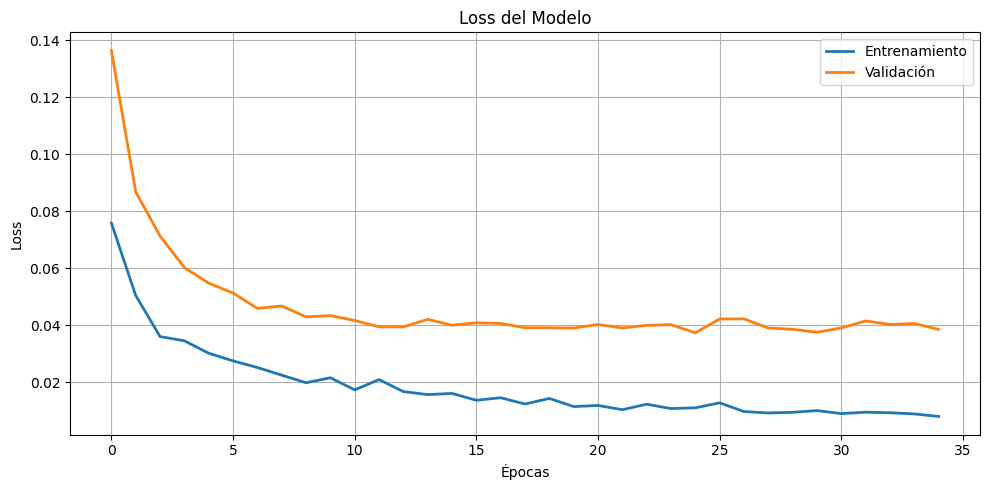

In [45]:
#==========================================================================================
# CURVA DE LOSS
#==========================================================================================

plt.figure(figsize=(10,5))

plt.plot(

    historial.history["loss"],

    label="Entrenamiento",

    linewidth=2

)

plt.plot(

    historial.history["val_loss"],

    label="Validación",

    linewidth=2

)

plt.title("Loss del Modelo")

plt.xlabel("Épocas")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(

    "loss_experimento.png",

    dpi=300

)

plt.show()

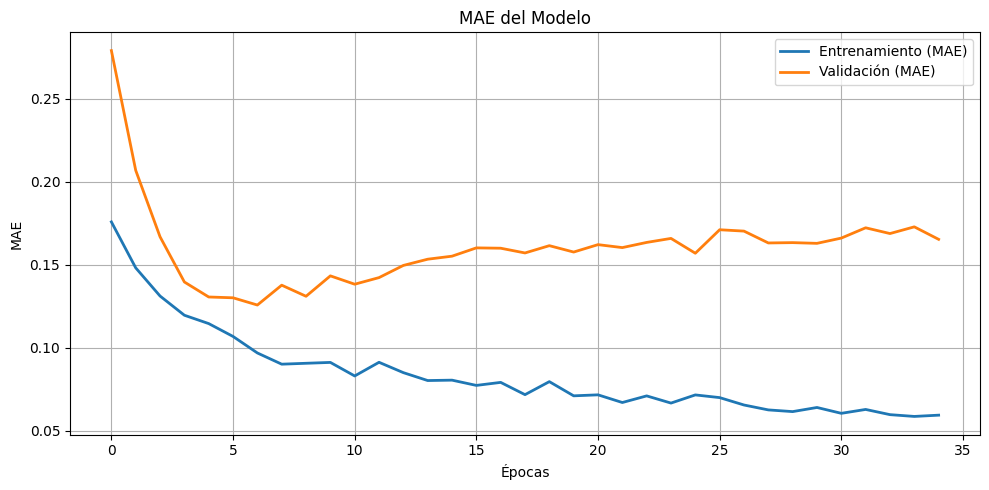

In [47]:
#==========================================================================================
# CURVA DE ACCURACY / MÉTRICA PRINCIPAL
#==========================================================================================

plt.figure(figsize=(10,5))

if TIPO_PROBLEMA == "Clasificación":
    plt.plot(
        historial.history["accuracy"],
        label="Entrenamiento",
        linewidth=2
    )
    plt.plot(
        historial.history["val_accuracy"],
        label="Validación",
        linewidth=2
    )
    plt.title("Accuracy del Modelo")
    plt.ylabel("Accuracy")
elif TIPO_PROBLEMA == "Regresión":
    plt.plot(
        historial.history["mae"],
        label="Entrenamiento (MAE)",
        linewidth=2
    )
    plt.plot(
        historial.history["val_mae"],
        label="Validación (MAE)",
        linewidth=2
    )
    plt.title("MAE del Modelo")
    plt.ylabel("MAE")

plt.xlabel("Épocas")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the plot with a dynamic name based on problem type
if TIPO_PROBLEMA == "Clasificación":
    plt.savefig("accuracy_experimento.png", dpi=300)
elif TIPO_PROBLEMA == "Regresión":
    plt.savefig("mae_experimento.png", dpi=300)

plt.show()

In [48]:
#==========================================================================================
# EXPORTACIÓN
#==========================================================================================

print()

print("="*90)
print("GRÁFICAS EXPORTADAS")
print("="*90)

print()

print("loss_experimento.png")

print("accuracy_experimento.png")


GRÁFICAS EXPORTADAS

loss_experimento.png
accuracy_experimento.png


## **M8. Guardar el modelo entrenado**

In [49]:
#==========================================================================================
# PERSISTENCIA DEL MODELO
#==========================================================================================

NOMBRE_MODELO = f"modelo_{EXPERIMENTO}_{VARIABLE_OBJETIVO}.keras"

modelo.save(

    NOMBRE_MODELO

)

print()

print("="*90)
print("MODELO EXPORTADO")
print("="*90)

print()

print(NOMBRE_MODELO)


MODELO EXPORTADO

modelo_Exp04_VolumenUtilDiarioMasa.keras


## **M9. Registro del Experimento**

In [50]:
#==========================================================================================
# FECHA DEL EXPERIMENTO
#==========================================================================================

from datetime import datetime

FECHA_EJECUCION = datetime.now()

print()

print("="*90)
print("FECHA DEL EXPERIMENTO")
print("="*90)

print()

print(FECHA_EJECUCION)


FECHA DEL EXPERIMENTO

2026-07-31 01:27:29.112317


In [52]:
#==========================================================================================
# REGISTRO DEL EXPERIMENTO
#==========================================================================================

registro_dict = {
    "Experimento": [EXPERIMENTO],
    "Fecha": [FECHA_EJECUCION],
    "Dominio": [DOMINIO],
    "Variable_Objetivo": [VARIABLE_OBJETIVO],
    "Modelo": [TIPO_MODELO],
    "Metodo_Transformacion": [METODO_TRANSFORMACION],
    "Ventana": [X.shape[1]],
    "Variables_Predictoras": [X.shape[2]],
    "Muestras": [X.shape[0]],
    "Train": [len(X_train)],
    "Validacion": [len(X_valid)],
    "Prueba": [len(X_test)],
    "Neuronas": [UNIDADES_LSTM],
    "Dropout": [DROPOUT],
    "Learning_Rate": [LEARNING_RATE],
    "Batch_Size": [BATCH_SIZE],
    "Epocas_Config": [EPOCAS],
    "Epocas_Ejecutadas": [len(historial.history["loss"])],
    "Loss_Train": [LOSS_FINAL],
    "Loss_Validacion": [VAL_LOSS_FINAL],
    "Loss_Prueba": [LOSS_TEST]
}

if TIPO_PROBLEMA == "Clasificación":
    registro_dict["Accuracy_Train"] = [ACC_FINAL]
    registro_dict["Accuracy_Validacion"] = [VAL_ACC_FINAL]
    registro_dict["Accuracy_Prueba"] = [ACC_TEST]
elif TIPO_PROBLEMA == "Regresión":
    registro_dict["MAE_Train"] = [MAE_FINAL]
    registro_dict["MAE_Validacion"] = [VAL_MAE_FINAL]
    registro_dict["RMSE_Train"] = [RMSE_FINAL]
    registro_dict["RMSE_Validacion"] = [VAL_RMSE_FINAL]
    registro_dict["MAE_Prueba"] = [MAE_TEST]
    registro_dict["RMSE_Prueba"] = [RMSE_TEST]

# These classification-like metrics are calculated in subsequent cells
# even if the problem type is regression, so they are generally available.
registro_dict["Accuracy"] = [accuracy]
registro_dict["Precision"] = [precision]
registro_dict["Recall"] = [recall]
registro_dict["F1_Score"] = [f1]
registro_dict["Especificidad"] = [especificidad]
registro_dict["Accuracy_Balanceada"] = [accuracy_balanceada]

registro_dict["Estado_General"] = [estado]
registro_dict["Tiempo_Segundos"] = [TIEMPO_ENTRENAMIENTO]

registro = pd.DataFrame(registro_dict)

print()

print("="*90)
print("REGISTRO DEL EXPERIMENTO")
print("="*90)

print()

display(registro)


REGISTRO DEL EXPERIMENTO



,Experimento,Fecha,Dominio,Variable_Objetivo,Modelo,Metodo_Transformacion,Ventana,Variables_Predictoras,Muestras,Train,...,MAE_Prueba,RMSE_Prueba,Accuracy,Precision,Recall,F1_Score,Especificidad,Accuracy_Balanceada,Estado_General,Tiempo_Segundos
0,Exp04,2026-07-31 01:27:29.112317,Gestión Hídrica,VolumenUtilDiarioMasa,LSTM,RobustScaler,12,8,516,361,...,0.219141,0.258861,0.948718,1.0,0.636364,0.777778,1.0,0.818182,MODELO APROBADO,10.650253


In [53]:
#==========================================================================================
# EXPORTACIÓN
#==========================================================================================

nombre_csv = f"registro_{EXPERIMENTO}.csv"

nombre_excel = f"registro_{EXPERIMENTO}.xlsx"

registro.to_csv(

    nombre_csv,

    index=False,

    encoding="utf-8-sig"

)

registro.to_excel(

    nombre_excel,

    index=False

)

print()

print("="*90)
print("ARCHIVOS GENERADOS")
print("="*90)

print()

print(nombre_csv)

print(nombre_excel)


ARCHIVOS GENERADOS

registro_Exp04.csv
registro_Exp04.xlsx


In [55]:
#==========================================================================================
# RESUMEN
#==========================================================================================

print()

print("="*90)
print("FRAMEWORK DE MODELADO FINALIZADO")
print("="*90)

print()

print(f"Experimento        : {EXPERIMENTO}")

print(f"Modelo             : {TIPO_MODELO}")

print(f"Objetivo           : {VARIABLE_OBJETIVO}")

print(f"Muestras           : {len(X)}")

if TIPO_PROBLEMA == "Clasificación":
    print(f"Accuracy Prueba    : {ACC_TEST:.4f}")
elif TIPO_PROBLEMA == "Regresión":
    print(f"MAE Prueba         : {MAE_TEST:.4f}")
    print(f"RMSE Prueba        : {RMSE_TEST:.4f}")

print(f"Tiempo             : {TIEMPO_ENTRENAMIENTO:.2f} segundos")

print()

print("Proceso completado correctamente.")


FRAMEWORK DE MODELADO FINALIZADO

Experimento        : Exp04
Modelo             : LSTM
Objetivo           : VolumenUtilDiarioMasa
Muestras           : 516
MAE Prueba         : 0.2191
RMSE Prueba        : 0.2589
Tiempo             : 10.65 segundos

Proceso completado correctamente.


## **M10. Bitácora Maestra**

In [56]:
#==========================================================================================
# BITÁCORA MAESTRA DEL FRAMEWORK
#==========================================================================================

import os

ARCHIVO_BITACORA = "bitacora_maestra_experimentos.xlsx"

print()

print("="*90)
print("BITÁCORA MAESTRA")
print("="*90)

print()

print(ARCHIVO_BITACORA)


BITÁCORA MAESTRA

bitacora_maestra_experimentos.xlsx


In [57]:
#==========================================================================================
# CARGA DE LA BITÁCORA
#==========================================================================================

if os.path.exists(ARCHIVO_BITACORA):

    bitacora = pd.read_excel(

        ARCHIVO_BITACORA

    )

else:

    bitacora = pd.DataFrame()

In [58]:
#==========================================================================================
# AGREGAR REGISTRO Y ORDENAMIENTO
#==========================================================================================

# Agregar el registro del experimento actual a la bitácora
if bitacora.empty:
    bitacora = registro.copy()
else:
    bitacora = pd.concat([bitacora, registro], ignore_index=True)

# Ordenar la bitácora
if not bitacora.empty:
    bitacora = bitacora.sort_values(
        by="Experimento"
    ).reset_index(
        drop=True
    )

In [59]:
#==========================================================================================
# EXPORTACIÓN
#==========================================================================================

bitacora.to_excel(

    ARCHIVO_BITACORA,

    index=False

)

bitacora.to_csv(

    "bitacora_maestra_experimentos.csv",

    index=False,

    encoding="utf-8-sig"

)

In [60]:
#==========================================================================================
# HISTÓRICO
#==========================================================================================

print()

print("="*90)
print("HISTÓRICO DEL FRAMEWORK")
print("="*90)

print()

display(bitacora)


HISTÓRICO DEL FRAMEWORK



,Experimento,Fecha,Dominio,Variable_Objetivo,Modelo,Metodo_Transformacion,Ventana,Variables_Predictoras,Muestras,Train,...,MAE_Prueba,RMSE_Prueba,Accuracy,Precision,Recall,F1_Score,Especificidad,Accuracy_Balanceada,Estado_General,Tiempo_Segundos
0,Exp04,2026-07-31 01:27:29.112317,Gestión Hídrica,VolumenUtilDiarioMasa,LSTM,RobustScaler,12,8,516,361,...,0.219141,0.258861,0.948718,1.0,0.636364,0.777778,1.0,0.818182,MODELO APROBADO,10.650253


## **M11. Centro Analítico del Framework**

In [61]:
#==========================================================================================
# SCRIPT 43
# CENTRO ANALÍTICO DEL FRAMEWORK
#==========================================================================================

import pandas as pd

ARCHIVO_BITACORA = "bitacora_maestra_experimentos.xlsx"

bitacora = pd.read_excel(

    ARCHIVO_BITACORA

)

print()

print("="*90)
print("CENTRO ANALÍTICO DEL FRAMEWORK")
print("="*90)

print()

display(bitacora.head())


CENTRO ANALÍTICO DEL FRAMEWORK



,Experimento,Fecha,Dominio,Variable_Objetivo,Modelo,Metodo_Transformacion,Ventana,Variables_Predictoras,Muestras,Train,...,MAE_Prueba,RMSE_Prueba,Accuracy,Precision,Recall,F1_Score,Especificidad,Accuracy_Balanceada,Estado_General,Tiempo_Segundos
0,Exp04,2026-07-31 01:27:29.112,Gestión Hídrica,VolumenUtilDiarioMasa,LSTM,RobustScaler,12,8,516,361,...,0.219141,0.258861,0.948718,1,0.636364,0.777778,1,0.818182,MODELO APROBADO,10.650253


In [63]:
import pandas as pd

#==========================================================================================
# RESUMEN GENERAL
#==========================================================================================

print()

print("="*90)
print("RESUMEN GENERAL")
print("="*90)

print()

if not bitacora.empty:
    print(f"Experimentos ejecutados : {len(bitacora)}")
    print(f"Modelos utilizados      : {bitacora['Modelo'].nunique()}")
    print(f"Variables objetivo      : {bitacora['Variable_Objetivo'].nunique()}")

    if 'Accuracy_Prueba' in bitacora.columns and bitacora['Accuracy_Prueba'].notna().any():
        print(f"Accuracy promedio       : {bitacora['Accuracy_Prueba'].mean():.4f}")

    if 'MAE_Prueba' in bitacora.columns and bitacora['MAE_Prueba'].notna().any():
        print(f"MAE promedio            : {bitacora['MAE_Prueba'].mean():.4f}")

    if 'RMSE_Prueba' in bitacora.columns and bitacora['RMSE_Prueba'].notna().any():
        print(f"RMSE promedio           : {bitacora['RMSE_Prueba'].mean():.4f}")

    print(f"Loss promedio           : {bitacora['Loss_Prueba'].mean():.4f}")
    print(f"Tiempo promedio (s)     : {bitacora['Tiempo_Segundos'].mean():.2f}")
else:
    print("La bitácora está vacía. No se pueden generar estadísticas.")


RESUMEN GENERAL

Experimentos ejecutados : 1
Modelos utilizados      : 1
Variables objetivo      : 1
MAE promedio            : 0.2191
RMSE promedio           : 0.2589
Loss promedio           : 0.0670
Tiempo promedio (s)     : 10.65


In [64]:
import numpy as np

print('\n==========================================================================================')
print('DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (y)')
print('==========================================================================================\n')

# Obtener los valores únicos y sus conteos del array y
unique_values, counts = np.unique(y, return_counts=True)

for val, count in zip(unique_values, counts):
    print(f"Valor '{int(val)}': {count} ocurrencias")


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (y)

Valor '0': 472 ocurrencias
Valor '1': 44 ocurrencias
